In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [66]:
metadata_path = "../data/amazon/raw/review_categories/All_Beauty.jsonl"
review = pd.read_json(metadata_path,
                    lines=True,
                    nrows=10000)
review.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-05 14:08:48.923,0,True
1,4,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-04 18:10:55.070,1,True
2,5,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,2020-05-16 21:41:06.052,2,True
3,1,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2022-01-28 18:13:50.220,0,True
4,5,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-30 10:02:43.534,0,True


In [67]:
print("Shape:", review.shape)


Shape: (10000, 10)


In [68]:
print("Columns:")
print(review.columns.tolist())

Columns:
['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']


In [69]:
review.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   rating             10000 non-null  int64         
 1   title              10000 non-null  str           
 2   text               10000 non-null  str           
 3   images             10000 non-null  object        
 4   asin               10000 non-null  str           
 5   parent_asin        10000 non-null  str           
 6   user_id            10000 non-null  str           
 7   timestamp          10000 non-null  datetime64[ms]
 8   helpful_vote       10000 non-null  int64         
 9   verified_purchase  10000 non-null  bool          
dtypes: bool(1), datetime64[ms](1), int64(2), object(1), str(5)
memory usage: 4.2+ MB


In [70]:
review.isnull().sum()

rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
dtype: int64

In [71]:
metadata_path = "../data/amazon/raw/meta_categories/meta_All_Beauty.jsonl"

metadata = pd.read_json(
    metadata_path,
    lines=True,
    nrows=10000
)

print("Metadata loaded successfully")
print("Shape:", metadata.shape)

Metadata loaded successfully
Shape: (10000, 14)


In [72]:
metadata.head()


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",4.8,10,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Howard Products,[],{'Package Dimensions': '7.1 x 5.5 x 3 inches; ...,B01CUPMQZE,NaN
1,All Beauty,Yes to Tomatoes Detoxifying Charcoal Cleanser ...,4.5,3,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Yes To,[],"{'Item Form': 'Powder', 'Skin Type': 'Acne Pro...",B076WQZGPM,NaN
2,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Levine Health Products,[],{'Manufacturer': 'Levine Health Products'},B000B658RI,NaN
3,All Beauty,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...",3.1,102,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Cherioll,[],"{'Brand': 'Cherioll', 'Item Form': 'Powder', '...",B088FKY3VD,NaN
4,All Beauty,Precision Plunger Bars for Cartridge Grips – 9...,4.3,7,"[Material: 304 Stainless Steel; Brass tip, Len...",[The Precision Plunger Bars are designed to wo...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Precision,[],{'UPC': '644287689178'},B07NGFDN6G,NaN


In [73]:
metadata.columns.tolist()

['main_category',
 'title',
 'average_rating',
 'rating_number',
 'features',
 'description',
 'price',
 'images',
 'videos',
 'store',
 'categories',
 'details',
 'parent_asin',
 'bought_together']

In [74]:
print("Reviews:", review.shape)
print("Unique users:", review["user_id"].nunique())
print("Unique products:", review["parent_asin"].nunique())

Reviews: (10000, 10)
Unique users: 6585
Unique products: 7067


In [75]:
review["rating"].value_counts().sort_index()

rating
1     858
2     581
3     977
4    1688
5    5896
Name: count, dtype: int64

In [76]:
review.isnull().sum()

rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
dtype: int64

In [77]:
metadata.isnull().sum()

main_category          0
title                  0
average_rating         0
rating_number          0
features               0
description            0
price               8151
images                 0
videos                 0
store                994
categories             0
details                0
parent_asin            0
bought_together    10000
dtype: int64

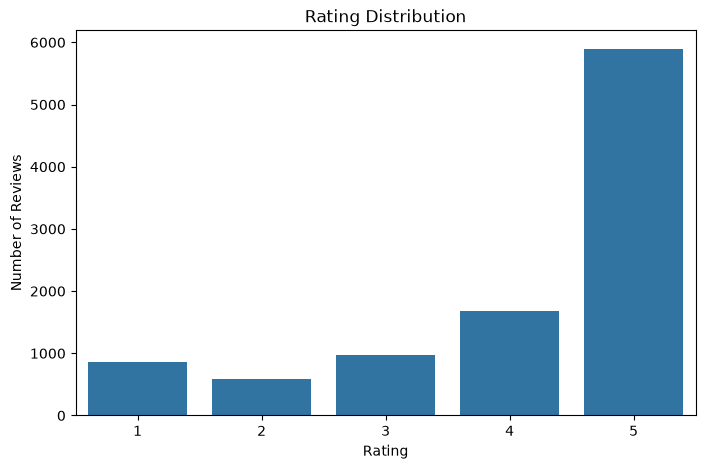

In [78]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=review,
    x="rating",
    order=[1, 2, 3, 4, 5]
)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

In [79]:
user_activity = review["user_id"].value_counts()

print(user_activity.describe())

count    6585.000000
mean        1.518603
std         3.775118
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max       165.000000
Name: count, dtype: float64


In [80]:
product_activity = review["parent_asin"].value_counts()

print(product_activity.describe())

count    7067.000000
mean        1.415028
std         1.283577
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        34.000000
Name: count, dtype: float64


In [81]:
review["rating"].value_counts(normalize=True).sort_index() * 100

rating
1     8.58
2     5.81
3     9.77
4    16.88
5    58.96
Name: proportion, dtype: float64

In [82]:
print("Users with 1 review:", (user_activity == 1).sum())
print("Users with >5 reviews:", (user_activity > 5).sum())
print("Users with >10 reviews:", (user_activity > 10).sum())

Users with 1 review: 5394
Users with >5 reviews: 113
Users with >10 reviews: 58


In [83]:
print("Products with 1 review:", (product_activity == 1).sum())
print("Products with >5 reviews:", (product_activity > 5).sum())
print("Products with >10 reviews:", (product_activity > 10).sum())

Products with 1 review: 5598
Products with >5 reviews: 109
Products with >10 reviews: 18


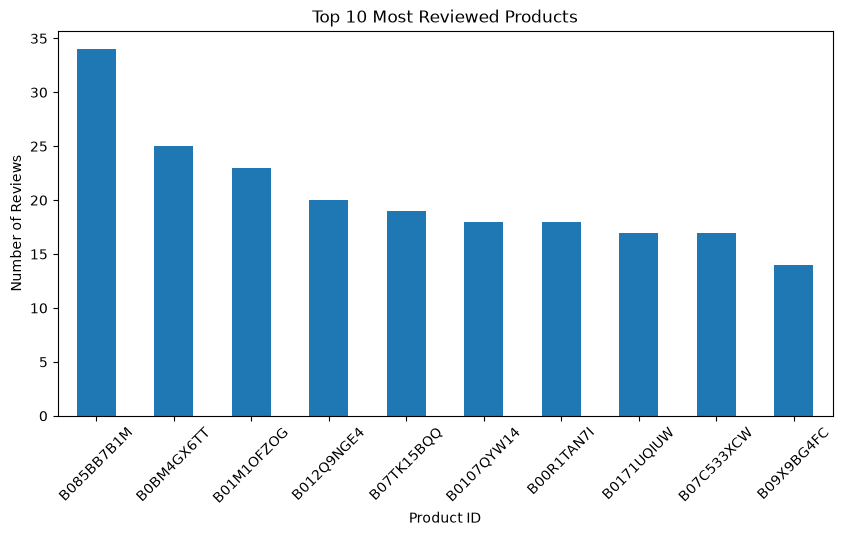

In [84]:
top_products = product_activity.head(10)

plt.figure(figsize=(10, 5))
top_products.plot(kind="bar")

plt.title("Top 10 Most Reviewed Products")
plt.xlabel("Product ID")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.show()

In [85]:
reviews_path = "../data/amazon/raw/review_categories/All_Beauty.jsonl"

chunks = pd.read_json(
    reviews_path,
    lines=True,
    chunksize=50000
)

print("Chunk reader created successfully")

Chunk reader created successfully


In [86]:
first_chunk = next(chunks)

print(first_chunk.shape)
first_chunk.head()

(50000, 10)


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-05 14:08:48.923,0,True
1,4,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-04 18:10:55.070,1,True
2,5,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,2020-05-16 21:41:06.052,2,True
3,1,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2022-01-28 18:13:50.220,0,True
4,5,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-30 10:02:43.534,0,True


In [87]:
from collections import Counter

user_counts = Counter()
product_counts = Counter()

reviews_path = "../data/amazon/raw/review_categories/All_Beauty.jsonl"

for chunk in pd.read_json(
    reviews_path,
    lines=True,
    chunksize=50000
):
    user_counts.update(chunk["user_id"])
    product_counts.update(chunk["parent_asin"])

print("Total unique users:", len(user_counts))
print("Total unique products:", len(product_counts))

Total unique users: 631986
Total unique products: 112565


In [88]:
user_count_series = pd.Series(user_counts)
product_count_series = pd.Series(product_counts)

print("USER ACTIVITY")
print(user_count_series.describe())

print("\nPRODUCT ACTIVITY")
print(product_count_series.describe())

USER ACTIVITY
count    631986.000000
mean          1.110037
std           0.753202
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         165.000000
dtype: float64

PRODUCT ACTIVITY
count    112565.000000
mean          6.232204
std          25.189840
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max        1962.000000
dtype: float64


In [89]:
print("Users with >= 2 reviews:", (user_count_series >= 2).sum())
print("Users with >= 5 reviews:", (user_count_series >= 5).sum())
print("Users with >= 10 reviews:", (user_count_series >= 10).sum())
print("Users with >= 20 reviews:", (user_count_series >= 20).sum())

Users with >= 2 reviews: 48433
Users with >= 5 reviews: 1620
Users with >= 10 reviews: 330
Users with >= 20 reviews: 117


In [90]:
print("Products with >= 2 reviews:", (product_count_series >= 2).sum())
print("Products with >= 5 reviews:", (product_count_series >= 5).sum())
print("Products with >= 10 reviews:", (product_count_series >= 10).sum())
print("Products with >= 20 reviews:", (product_count_series >= 20).sum())

Products with >= 2 reviews: 64999
Products with >= 5 reviews: 27533
Products with >= 10 reviews: 13257
Products with >= 20 reviews: 6044


In [91]:
reviews_path = "../data/amazon/raw/review_categories/All_Beauty.jsonl"

filtered_chunks = []

for chunk in pd.read_json(
    reviews_path,
    lines=True,
    chunksize=50000
):
    # Keep users with at least 2 reviews
    chunk = chunk[chunk["user_id"].isin(
        user_count_series[user_count_series >= 2].index
    )]

    # Keep products with at least 5 reviews
    chunk = chunk[chunk["parent_asin"].isin(
        product_count_series[product_count_series >= 5].index
    )]

    filtered_chunks.append(
        chunk[["user_id", "parent_asin", "rating", "timestamp", "verified_purchase"]]
    )

filtered_reviews = pd.concat(filtered_chunks, ignore_index=True)

print("Filtered dataset shape:", filtered_reviews.shape)

Filtered dataset shape: (88895, 5)


In [92]:
print("Unique users:", filtered_reviews["user_id"].nunique())
print("Unique products:", filtered_reviews["parent_asin"].nunique())
print("Total interactions:", len(filtered_reviews))

Unique users: 44155
Unique products: 20987
Total interactions: 88895


In [93]:
filtered_reviews.head()


,user_id,parent_asin,rating,timestamp,verified_purchase
0,AGKHLEW2SOWHNMFQIJGBECAF7INQ,B00YQ6X8EO,5,2020-05-05 14:08:48.923,True
1,AGKHLEW2SOWHNMFQIJGBECAF7INQ,B081TJ8YS3,4,2020-05-04 18:10:55.070,True
2,AFSKPY37N3C43SOI5IEXEK5JSIYA,B08P2DZB4X,5,2021-07-27 13:04:04.559,False
3,AFSKPY37N3C43SOI5IEXEK5JSIYA,B086QY6T7N,5,2021-07-18 13:21:51.145,False
4,AFSKPY37N3C43SOI5IEXEK5JSIYA,B07RBSLNFR,5,2021-05-16 17:00:30.697,False


In [94]:
print("Missing values:")
print(filtered_reviews.isnull().sum())

print("\nDuplicate rows:")
print(filtered_reviews.duplicated().sum())

print("\nRating distribution:")
print(filtered_reviews["rating"].value_counts().sort_index())

Missing values:
user_id              0
parent_asin          0
rating               0
timestamp            0
verified_purchase    0
dtype: int64

Duplicate rows:
6223

Rating distribution:
rating
1     9227
2     4905
3     7821
4    12109
5    54833
Name: count, dtype: int64


In [95]:
print(filtered_reviews["timestamp"].head())
print(filtered_reviews["timestamp"].dtype)

0   2020-05-05 14:08:48.923
1   2020-05-04 18:10:55.070
2   2021-07-27 13:04:04.559
3   2021-07-18 13:21:51.145
4   2021-05-16 17:00:30.697
Name: timestamp, dtype: datetime64[ms]
datetime64[ms]


In [96]:
filtered_reviews = filtered_reviews.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", filtered_reviews.shape)
print("Remaining duplicates:", filtered_reviews.duplicated().sum())

Shape after removing duplicates: (82672, 5)
Remaining duplicates: 0


In [97]:
print(filtered_reviews["rating"].value_counts().sort_index())

rating
1     8256
2     4544
3     7319
4    11465
5    51088
Name: count, dtype: int64


In [98]:
print("Interactions per user:")
print(filtered_reviews["user_id"].value_counts().describe())

print("\nInteractions per product:")
print(filtered_reviews["parent_asin"].value_counts().describe())

Interactions per user:
count    44155.000000
mean         1.872313
std          1.857837
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max        119.000000
Name: count, dtype: float64

Interactions per product:
count    20987.000000
mean         3.939200
std          6.743184
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max        232.000000
Name: count, dtype: float64


In [99]:
# Sort interactions chronologically for each user
filtered_reviews = filtered_reviews.sort_values(
    ["user_id", "timestamp"]
).reset_index(drop=True)

# Users with at least 2 interactions
user_counts = filtered_reviews["user_id"].value_counts()
eligible_users = user_counts[user_counts >= 2].index

# Split
test_mask = (
    filtered_reviews["user_id"].isin(eligible_users)
    & filtered_reviews.groupby("user_id").cumcount()
      .eq(filtered_reviews.groupby("user_id")["user_id"].transform("size") - 1)
)

test_data = filtered_reviews[test_mask].copy()
train_data = filtered_reviews[~test_mask].copy()

print("Training interactions:", len(train_data))
print("Testing interactions:", len(test_data))
print("Training users:", train_data["user_id"].nunique())
print("Testing users:", test_data["user_id"].nunique())

Training interactions: 55496
Testing interactions: 27176
Training users: 44155
Testing users: 27176


In [100]:
check = (
    train_data.groupby("user_id")["timestamp"]
    .max()
    .to_frame("last_train")
    .join(
        test_data.set_index("user_id")["timestamp"]
        .rename("test_time")
    )
)

print("Users checked:", len(check))
print("Correct temporal order:",
      (check["test_time"] > check["last_train"]).sum())
print("Incorrect temporal order:",
      (check["test_time"] <= check["last_train"]).sum())

Users checked: 44155
Correct temporal order: 27176
Incorrect temporal order: 0


In [101]:
product_stats = (
    train_data
    .groupby("parent_asin")["rating"]
    .agg(["count", "mean"])
    .reset_index()
)

product_stats.columns = [
    "parent_asin",
    "rating_count",
    "average_rating"
]

product_stats.head()

,parent_asin,rating_count,average_rating
0,069267599X,3,5.0
1,1453085815,2,2.0
2,4293845755,2,1.0
3,6041134546,2,2.5
4,8674394329,2,4.0


In [102]:
product_stats.sort_values(
    "rating_count",
    ascending=False
).head(10)

,parent_asin,rating_count,average_rating
13141,B085BB7B1M,164,4.664634
17547,B0BM4GX6TT,150,4.100000
3546,B012Q9NGE4,109,4.201835
3391,B0107QYW14,107,4.084112
6004,B01M1OFZOG,95,4.115789
2619,B00R1TAN7I,81,3.913580
16804,B09C2ZW2GL,78,4.641026
226,B000X20Y4C,76,4.381579
8837,B07C533XCW,75,4.653333
7572,B074KD4PX2,73,4.191781


In [103]:
C = train_data["rating"].mean()

m = 10

product_stats["weighted_score"] = (
    (product_stats["rating_count"] /
     (product_stats["rating_count"] + m))
    * product_stats["average_rating"]
    +
    (m /
     (product_stats["rating_count"] + m))
    * C
)

print("Global average rating:", C)

Global average rating: 4.132622170967277


In [104]:
m = 10

product_stats["weighted_score"] = (
    (product_stats["rating_count"] /
     (product_stats["rating_count"] + m))
    * product_stats["average_rating"]
    +
    (m /
     (product_stats["rating_count"] + m))
    * C
)

In [105]:
top_products = product_stats.sort_values(
    "weighted_score",
    ascending=False
).head(10)

top_products

,parent_asin,rating_count,average_rating,weighted_score
16877,B09FFQT1KK,59,4.881356,4.772844
11944,B07WVBDLG9,24,5.000000,4.744889
6867,B06Y44MMT6,32,4.875000,4.698243
2004,B00KL0HV56,22,4.954545,4.697694
5398,B01I2MU2JQ,59,4.762712,4.671395
6394,B01N47XMWS,17,4.941176,4.641712
919,B007QG7G3U,17,4.941176,4.641712
15244,B08KW15N2L,14,5.000000,4.638593
13141,B085BB7B1M,164,4.664634,4.634059
6553,B06VWPZN56,35,4.771429,4.629472


In [106]:
top_product_ids = top_products["parent_asin"].tolist()

metadata[
    metadata["parent_asin"].isin(top_product_ids)
][["parent_asin", "title"]]

,parent_asin,title


In [107]:
top_product_ids = set(top_products["parent_asin"])

metadata_matches = []

for chunk in pd.read_json(
    metadata_path,
    lines=True,
    chunksize=10000
):
    matches = chunk[
        chunk["parent_asin"].isin(top_product_ids)
    ]

    if not matches.empty:
        metadata_matches.append(matches)

top_metadata = pd.concat(
    metadata_matches,
    ignore_index=True
)

print("Products found:", len(top_metadata))

Products found: 10


In [108]:
top_metadata[
    ["parent_asin", "title", "average_rating", "rating_number"]
]

,parent_asin,title,average_rating,rating_number
0,B09FFQT1KK,Sun Labs Self Tanning Mitt Applicator - 1 Sunl...,4.6,1773
1,B08KW15N2L,Original Pedi-Sox brand Toeless Socks for Pedi...,4.4,246
2,B07WVBDLG9,7Rainbows 10pcs Girls Unicorn Hair Bows On Hea...,4.6,2831
3,B06Y44MMT6,Segbeauty empty bottle 082,4.7,4251
4,B01I2MU2JQ,Sky Organics Fractionated Coconut Oil for Body...,4.7,1153
5,B085BB7B1M,Salux Nylon Japanese Beauty Skin Bath Wash Clo...,4.7,9101
6,B01N47XMWS,"1.5"" Heart Shape Kraft Paper Thank You Adhesiv...",4.8,10913
7,B06VWPZN56,"DMSO Cream With Aloe Vera - Lavender Scented, ...",4.2,2255
8,B00KL0HV56,Shea Butter -100% Pure RAW Unrefined African S...,4.0,286
9,B007QG7G3U,Coochy Shave Creme,4.4,290


collaberative filtering 

In [109]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix

In [110]:
# Create unique user and product lists
users = train_data["user_id"].unique()
products = train_data["parent_asin"].unique()

# Map IDs to integer indices
user_to_index = {user: i for i, user in enumerate(users)}
product_to_index = {product: i for i, product in enumerate(products)}

In [111]:
row_indices = train_data["user_id"].map(user_to_index)
col_indices = train_data["parent_asin"].map(product_to_index)

user_item_matrix = csr_matrix(
    (
        train_data["rating"].astype(float),
        (row_indices, col_indices)
    ),
    shape=(len(users), len(products))
)

In [112]:
print("Matrix shape:", user_item_matrix.shape)
print("Number of ratings:", user_item_matrix.nnz)
print("Users:", len(users))
print("Products:", len(products))

Matrix shape: (44155, 17662)
Number of ratings: 55437
Users: 44155
Products: 17662


In [113]:
from sklearn.metrics.pairwise import cosine_similarity

# Transpose so products become rows
item_user_matrix = user_item_matrix.T

print("Item-user matrix shape:", item_user_matrix.shape)

Item-user matrix shape: (17662, 44155)


In [114]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate similarity for the first product
similarity_scores = cosine_similarity(
    item_user_matrix[0],
    item_user_matrix
).flatten()

print("Similarity array shape:", similarity_scores.shape)
print("First 10 scores:", similarity_scores[:10])

Similarity array shape: (17662,)
First 10 scores: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [115]:
# Get indices of the most similar products
similar_items = np.argsort(similarity_scores)[::-1]

# Exclude the product itself
similar_items = similar_items[similar_items != 0]

# Select the top 5
top_5_indices = similar_items[:5]

# Get product IDs and similarity scores
for index in top_5_indices:
    product_id = products[index]
    score = similarity_scores[index]
    print(product_id, score)

B07QV3T5FT 0.5773502691896258
B07M6CDGP8 0.15713484026367724
B093QLF6ZQ 0.0
B08B4N5BXZ 0.0
B08CVTNQP1 0.0


In [116]:
similar_product_ids = [products[i] for i in top_5_indices]

similar_metadata = []

for chunk in pd.read_json(
    metadata_path,
    lines=True,
    chunksize=10000
):
    matches = chunk[
        chunk["parent_asin"].isin(similar_product_ids)
    ]

    if not matches.empty:
        similar_metadata.append(matches)

similar_products = pd.concat(
    similar_metadata,
    ignore_index=True
)

print(similar_products[["parent_asin", "title"]])

  parent_asin                                              title
0  B093QLF6ZQ  Eyelash and Brow Growth Serum Irritation Free ...
1  B08B4N5BXZ  12 Pieces Nail Polish Pen 5 ml One Step Nail G...
2  B07M6CDGP8  7 Packs Dreadlocs Faux Locs Hair Extensions 18...
3  B08CVTNQP1  Disney Frozen - Townley Girl Mega Nail Set wit...
4  B07QV3T5FT  6 Packs 18inch Striaght Goddess Locs With Curl...


In [117]:
def recommend_similar_products(product_id, top_n=5):
    product_index = product_to_index.get(product_id)

    if product_index is None:
        return "Product not found"

    scores = cosine_similarity(
        item_user_matrix[product_index],
        item_user_matrix
    ).flatten()

    similar_indices = np.argsort(scores)[::-1]

    recommendations = []

    for index in similar_indices:
        if index == product_index:
            continue

        if scores[index] <= 0:
            break

        recommendations.append({
            "parent_asin": products[index],
            "similarity": scores[index]
        })

        if len(recommendations) == top_n:
            break

    return pd.DataFrame(recommendations)

In [118]:
recommend_similar_products(products[0], top_n=5)

,parent_asin,similarity
0,B07QV3T5FT,0.577350
1,B07M6CDGP8,0.157135


In [119]:
def recommend_for_user(user_id, top_n=5):
    user_history = train_data[
        train_data["user_id"] == user_id
    ]

    if user_history.empty:
        return pd.DataFrame(
            columns=["parent_asin", "score"]
        )

    scores = {}

    seen_products = set(user_history["parent_asin"])

    for _, row in user_history.iterrows():
        product_id = row["parent_asin"]
        rating = row["rating"]

        product_index = product_to_index[product_id]

        # Get similarities for this product
        similarities = item_similarity.getrow(product_index)

        for index, similarity in zip(
            similarities.indices,
            similarities.data
        ):
            recommended_id = products[index]

            if recommended_id in seen_products:
                continue

            scores[recommended_id] = (
                scores.get(recommended_id, 0)
                + similarity * rating
            )

    recommendations = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )[:top_n]

    return pd.DataFrame(
        recommendations,
        columns=["parent_asin", "score"]
    )

In [120]:
sample_user = train_data["user_id"].iloc[0]

print("User ID:", sample_user)

recommendations = recommend_for_user(
    sample_user,
    top_n=5
)

print(recommendations)

User ID: AE224BWJ4436CVNISRJAMPHBAZJA
  parent_asin     score
0  B07QV3T5FT  0.577350
1  B07M6CDGP8  0.157135


In [121]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate sparse item-item similarities
item_similarity = cosine_similarity(
    item_user_matrix,
    dense_output=False
)

print("Similarity matrix shape:", item_similarity.shape)
print("Non-zero similarities:", item_similarity.nnz)

Similarity matrix shape: (17662, 17662)
Non-zero similarities: 152586


In [122]:
recommend_for_user(sample_user, top_n=5)


,parent_asin,score
0,B07QV3T5FT,0.577350
1,B07M6CDGP8,0.157135
